# Circuit Workload Experiments

Run and compare scheduler performance across different circuit workloads:
- **Widths**: Small (4-8), Medium (8-12), Large (12-16), XLarge (16-20)
- **Depths**: Shallow, Medium, Deep

## Setup
I did the following in VSCode in WSL, not sure if it will work in other environments.

Run the following commands to get a proper kernel:
```bash
source .venv/bin/activate

pip install pandas matplotlib seaborn
```

Then, in the Jupyter notebook, select the .venv kernel to run the notebook


In [21]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
BASE_DIR = Path.cwd()
RESULTS_DIR = BASE_DIR / "results" / "circuit_workload_shapes"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")

Base directory: /home/soud09/code_projects/dmlsys_lab/quantum_computing/DQC_Scheduler/experiment_notebooks
Results will be saved to: /home/soud09/code_projects/dmlsys_lab/quantum_computing/DQC_Scheduler/experiment_notebooks/results/circuit_workload_shapes


## Experiment Configurations

In [22]:
# Define all workload experiments
WORKLOADS = {
    # Width comparisons
    "width_small": {
        "description": "Small width (4-8 qubits)",
        "env": {
            "QDC_N_JOBS": "50",
            "QDC_WIDE_WIDTHS": "4,6,8",
            "QDC_MED_EXPECT_WIDTHS": "4,6",
        },
    },
    "width_medium": {
        "description": "Medium width (8-12 qubits)",
        "env": {
            "QDC_N_JOBS": "50",
            "QDC_WIDE_WIDTHS": "8,10,12",
            "QDC_MED_EXPECT_WIDTHS": "6,8,10",
        },
    },
    "width_large": {
        "description": "Large width (12-16 qubits - forces cutting)",
        "env": {
            "QDC_N_JOBS": "50",
            "QDC_WIDE_WIDTHS": "12,14,16",
            "QDC_MED_EXPECT_WIDTHS": "10,12",
        },
    },
    "width_xlarge": {
        "description": "Very large width (16-20 qubits - definitely needs cutting)",
        "env": {
            "QDC_N_JOBS": "50",
            "QDC_WIDE_WIDTHS": "16,18,20",
            "QDC_MED_EXPECT_WIDTHS": "12,14",
        },
    },
    # Depth comparisons
    "depth_shallow": {
        "description": "Shallow circuits (low depth)",
        "env": {"QDC_N_JOBS": "60", "QDC_PCT_WIDE": "0.20"},
    },
    "depth_medium": {
        "description": "Medium depth",
        "env": {
            "QDC_N_JOBS": "60",
            "QDC_PCT_WIDE": "0.35",
            "QDC_PCT_EXPECT": "0.50",
        },
    },
    "depth_deep": {
        "description": "Deep circuits (high depth expectations)",
        "env": {
            "QDC_N_JOBS": "60",
            "QDC_PCT_WIDE": "0.50",
            "QDC_PCT_EXPECT": "0.60",
        },
    }
}

print(f"Total workloads defined: {len(WORKLOADS)}")
for name, cfg in WORKLOADS.items():
    print(f"  - {name}: {cfg['description']}")

Total workloads defined: 7
  - width_small: Small width (4-8 qubits)
  - width_medium: Medium width (8-12 qubits)
  - width_large: Large width (12-16 qubits - forces cutting)
  - width_xlarge: Very large width (16-20 qubits - definitely needs cutting)
  - depth_shallow: Shallow circuits (low depth)
  - depth_medium: Medium depth
  - depth_deep: Deep circuits (high depth expectations)


In [23]:
import qdc_sched.demo.run_demo_workload as demo_mod

def run_workload(workload_name: str, env_overrides: dict, dry_run: bool = False, results_root: Path = RESULTS_DIR) -> Path:
    """Run a single workload experiment directly (faster than subprocess)."""
    out_dir = results_root / f"workload_{workload_name}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # Setup environment
    old_env = {}
    for key, val in env_overrides.items():
        old_env[key] = os.environ.get(key)
        os.environ[key] = str(val)
    
    old_env["QDC_OUTDIR"] = os.environ.get("QDC_OUTDIR")
    os.environ["QDC_OUTDIR"] = str(out_dir)
    
    print(f"\n{'='*70}")
    print(f"Running: {workload_name}")
    print(f"Output directory: {out_dir}")
    print(f"Environment variables:")
    for key, val in sorted(env_overrides.items()):
        print(f"  {key}={val}")
    print(f"{'='*70}")
    
    try:
        if not dry_run:
            demo_mod.run_workload(full_eval=False)
        print(f"✓ {workload_name} completed successfully")
    except Exception as e:
        print(f"✗ {workload_name} failed with error: {e}")
        raise
    finally:
        # Restore environment
        for key, val in old_env.items():
            if val is None:
                os.environ.pop(key, None)
            else:
                os.environ[key] = val
    
    return out_dir

# Choose which workloads to run (modify as needed)
WORKLOADS_TO_RUN = list(WORKLOADS.keys())  # Run all

print(f"Will run {len(WORKLOADS_TO_RUN)} workloads")
print("Workloads to run:")
for name in WORKLOADS_TO_RUN:
    print(f"  - {name}")

Will run 7 workloads
Workloads to run:
  - width_small
  - width_medium
  - width_large
  - width_xlarge
  - depth_shallow
  - depth_medium
  - depth_deep


In [24]:
# Run all experiments

run_results = {}
for workload_name in WORKLOADS_TO_RUN:
    cfg = WORKLOADS[workload_name]
    try:
        out_dir = run_workload(workload_name, cfg["env"], dry_run=False)
        run_results[workload_name] = out_dir
        print(f"✓ {workload_name} completed")
    except Exception as e:
        print(f"✗ {workload_name} failed: {e}")

print(f"\nCompleted {len(run_results)}/{len(WORKLOADS_TO_RUN)} workloads")


Running: width_small
Output directory: /home/soud09/code_projects/dmlsys_lab/quantum_computing/DQC_Scheduler/experiment_notebooks/results/circuit_workload_shapes/workload_width_small
Environment variables:
  QDC_MED_EXPECT_WIDTHS=4,6
  QDC_N_JOBS=50
  QDC_WIDE_WIDTHS=4,6,8
[DEMO] reserve_nonsim = True
[DEMO] QDC_EXCLUDE_QPU_C = True

================ REAL WORKLOAD RUN ================
full_eval: False
timing_mode: analytic
aer_repeats: 1
jobs: 50
congestion_burst_s: 15.0
burst_starts_s: [15.0, 40.0]
wide_jobs: 8
wide_family: random_cx
wide_depths: [16, 24, 32]
wide_shots: [500, 1000, 2000]
wide_align_to_bursts: True
[t=   0.50] reserve_calls={'qpu_B': 2} | pending=0 active_res=0
[t=   3.00] reserve_calls={'qpu_B': 5} | pending=0 active_res=0
[t=   5.90] reserve_calls={'qpu_B': 8} | pending=0 active_res=0
[t=   8.40] reserve_calls={'qpu_B': 13} | pending=0 active_res=0
[t=  10.90] reserve_calls={'qpu_B': 17} | pending=0 active_res=0
[WIDE-DBG] job=J006 kind=B_CUT_SINGLE_SEQ qpu_id=qpu_

## Results Analysis

In [25]:
# Load all workload records and build shape-level summaries
records = []
for p in sorted(RESULTS_DIR.glob("workload_*/records.csv")):
    d = pd.read_csv(p)
    d["workload"] = p.parent.name.replace("workload_", "")
    records.append(d)

all_records = pd.concat(records, ignore_index=True)
all_records["shape_group"] = all_records["workload"].str.split("_").str[0]

workload_summary = (
    all_records.groupby(["workload", "shape_group"], as_index=False)[["end_to_end_s", "fidelity_proxy"]]
    .mean()
    .sort_values("workload")
)

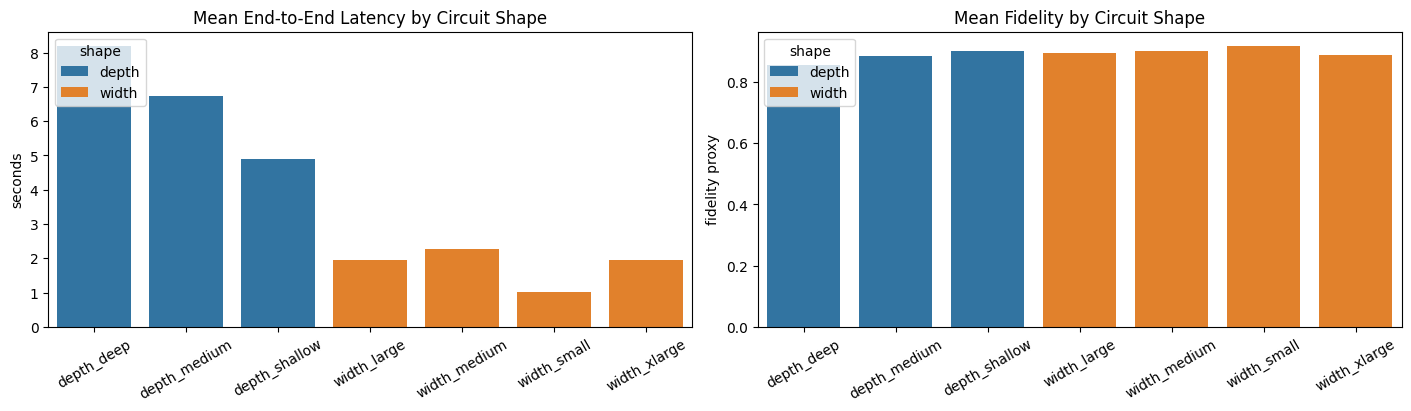

In [26]:
# 1) Overall strategy comparison across circuit shapes (workload means)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sns.barplot(data=workload_summary, x="workload", y="end_to_end_s", hue="shape_group", dodge=False, ax=axes[0])
axes[0].set_title("Mean End-to-End Latency by Circuit Shape")
axes[0].set_xlabel("")
axes[0].set_ylabel("seconds")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="shape", loc="upper left")

sns.barplot(data=workload_summary, x="workload", y="fidelity_proxy", hue="shape_group", dodge=False, ax=axes[1])
axes[1].set_title("Mean Fidelity by Circuit Shape")
axes[1].set_xlabel("")
axes[1].set_ylabel("fidelity proxy")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="shape", loc="upper left")

plt.show()

## No-Plan-C Experiment Set
Run the same workload set again, but force `allow_multi_qpu=False` for all jobs so Plan C is not considered.

In [27]:
# Run all workloads again with Plan C disabled
from dataclasses import replace

NO_C_RESULTS_DIR = RESULTS_DIR / "results_no_plan_c"
NO_C_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

orig_make_workload = demo_mod.make_workload

def make_workload_no_plan_c(*args, **kwargs):
    wl, wide_ids = orig_make_workload(*args, **kwargs)
    for i, (submit_s, job) in enumerate(wl):
        if getattr(job, "constraints", None) is not None:
            wl[i] = (
                submit_s,
                replace(job, constraints=replace(job.constraints, allow_multi_qpu=False)),
            )
    return wl, wide_ids

run_results_no_plan_c = {}
demo_mod.make_workload = make_workload_no_plan_c
try:
    for workload_name in WORKLOADS_TO_RUN:
        cfg = WORKLOADS[workload_name]
        out_dir = run_workload(workload_name, cfg["env"], dry_run=False, results_root=NO_C_RESULTS_DIR)
        run_results_no_plan_c[workload_name] = out_dir
finally:
    demo_mod.make_workload = orig_make_workload

print(f"Completed {len(run_results_no_plan_c)}/{len(WORKLOADS_TO_RUN)} no-Plan-C workloads")


Running: width_small
Output directory: /home/soud09/code_projects/dmlsys_lab/quantum_computing/DQC_Scheduler/experiment_notebooks/results/circuit_workload_shapes/results_no_plan_c/workload_width_small
Environment variables:
  QDC_MED_EXPECT_WIDTHS=4,6
  QDC_N_JOBS=50
  QDC_WIDE_WIDTHS=4,6,8
[DEMO] reserve_nonsim = True
[DEMO] QDC_EXCLUDE_QPU_C = True

================ REAL WORKLOAD RUN ================
full_eval: False
timing_mode: analytic
aer_repeats: 1
jobs: 50
congestion_burst_s: 15.0
burst_starts_s: [15.0, 40.0]
wide_jobs: 8
wide_family: random_cx
wide_depths: [16, 24, 32]
wide_shots: [500, 1000, 2000]
wide_align_to_bursts: True
[t=   0.50] reserve_calls={'qpu_B': 2} | pending=0 active_res=0
[t=   3.00] reserve_calls={'qpu_B': 5} | pending=0 active_res=0
[t=   5.90] reserve_calls={'qpu_B': 8} | pending=0 active_res=0
[t=   8.40] reserve_calls={'qpu_B': 13} | pending=0 active_res=0
[t=  10.90] reserve_calls={'qpu_B': 17} | pending=0 active_res=0
[WIDE-DBG] job=J006 kind=B_CUT_SING

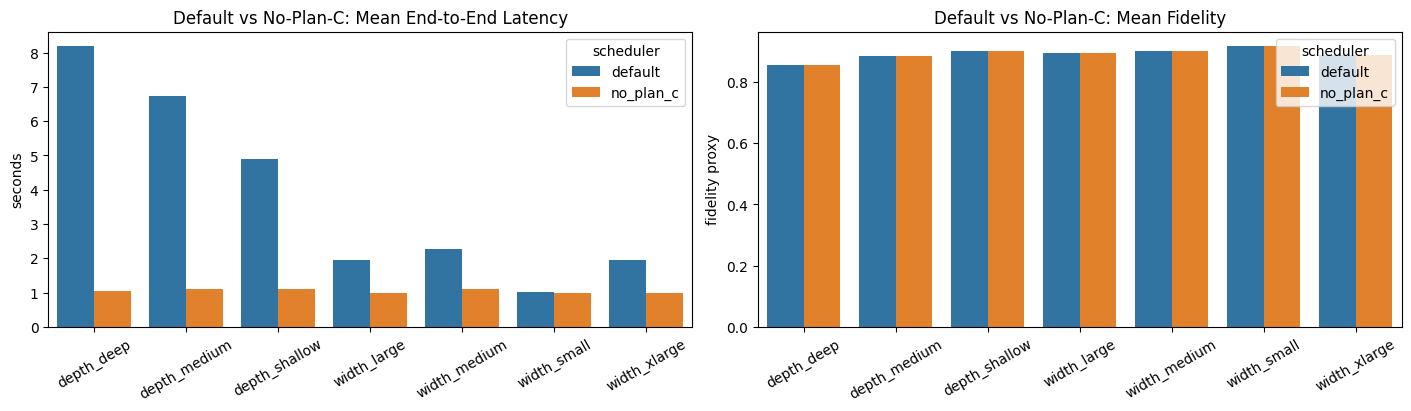

In [28]:
# Compare default scheduler vs no-Plan-C
def load_summary(results_root: Path, label: str) -> pd.DataFrame:
    records = []
    for p in sorted(results_root.glob("workload_*/records.csv")):
        d = pd.read_csv(p)
        d["workload"] = p.parent.name.replace("workload_", "")
        d["scheduler"] = label
        records.append(d)
    df = pd.concat(records, ignore_index=True)
    return (
        df.groupby(["workload", "scheduler"], as_index=False)[["end_to_end_s", "fidelity_proxy"]]
        .mean()
        .sort_values(["workload", "scheduler"])
    )

cmp_df = pd.concat([
    load_summary(RESULTS_DIR, "default"),
    load_summary(NO_C_RESULTS_DIR, "no_plan_c"),
])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sns.barplot(data=cmp_df, x="workload", y="end_to_end_s", hue="scheduler", ax=axes[0])
axes[0].set_title("Default vs No-Plan-C: Mean End-to-End Latency")
axes[0].set_xlabel("")
axes[0].set_ylabel("seconds")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=cmp_df, x="workload", y="fidelity_proxy", hue="scheduler", ax=axes[1])
axes[1].set_title("Default vs No-Plan-C: Mean Fidelity")
axes[1].set_xlabel("")
axes[1].set_ylabel("fidelity proxy")
axes[1].tick_params(axis="x", rotation=30)

plt.show()